### データセットなど準備

In [ ]:
# import
try:
    import cupy as np
    print('GPU!')
except ImportError:
    import numpy as np

import matplotlib.pyplot as plt
import pickle

GPU!


In [ ]:
from google.colab import drive

# Google Driveをマウント
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
c_names = {
    0: 'euro',
    1: 'tyuutou',
    2: 'asia',
    3: 'africa'
}
import matplotlib.pyplot as plt
# データセットの画像を表示するための関数
def show_dataset(x, y):
    plt.figure(figsize=(8, 8))
    for i in range(0, 25):
        plt.subplot(5, 5, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(x[i].get())  # GPUの場合、.get() が必要
        plt.xlabel(c_names[y[i].item()])  # GPUの場合、.item() が必要
    plt.show()


(240, 32, 32, 3) (240,)


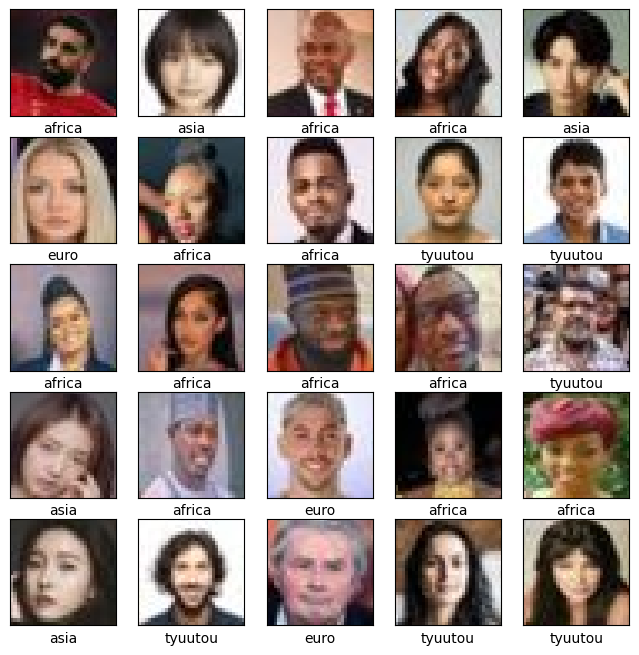

In [ ]:
# データセットのロード
npz = np.load('/content/drive/MyDrive/images_data.npz')
X = npz['images']#入力
T = npz['labels']#出力
# 確認
print(X.shape, T.shape)
show_dataset(X, T)

In [ ]:
# (b,h,w,c),dtypeはuint8なので、変換する
X = X.transpose(0, 3, 1, 2).astype(np.float16)
X /= 255.  # 正規化

# tをone-hotにする
T = np.eye(len(c_names))[T].astype(np.float16)

# train/validationに適当に分割　下変えてもあまり変わらないかも
split = 192
x_train = X[:split].copy()
t_train = T[:split].copy()
x_valid = X[split:].copy()
t_valid = T[split:].copy()
print(x_train.shape, t_train.shape)
print(x_valid.shape, t_valid.shape)

(192, 3, 32, 32) (192, 4)
(48, 3, 32, 32) (48, 4)


### これまでに実装したクラスのまとめ

In [ ]:
def im2col(x, w_size, stride, pad_size):
    x_n, c, x_h, x_w = x.shape
    w_h, w_w = w_size
    s_h, s_w = stride
    o_h = ((x_h - w_h + 2 * pad_size) // s_h) + 1
    o_w = ((x_w - w_w + 2 * pad_size) // s_w) + 1

    # パディング処理
    x = np.pad(x, [(0, 0), (0, 0), (pad_size, pad_size), (pad_size, pad_size)])

    # colを定義
    col = np.zeros((x_n, c, w_h, w_w, o_h, o_w))

    # im2col本体
    for i in range(w_h):
        for j in range(w_w):
            col[:, :, i, j, :, :] = x[:, :, i:i+o_h*s_h:s_h, j:j+o_w*s_w:s_w]

    col = col.transpose(0, 4, 5, 1, 2, 3).reshape(x_n * o_h * o_w, -1)
    return col

In [ ]:
def col2im(col_x, x_shape,  w_size, stride, pad_size):
    x_n, c, x_h, x_w = x_shape
    w_h, w_w = w_size
    s_h, s_w = stride
    o_h = ((x_h - w_h + 2 * pad_size) // s_h) + 1
    o_w = ((x_w - w_w + 2 * pad_size) // s_w) + 1

    col_x = col_x.reshape(x_n, o_h, o_w, c, w_h, w_w).transpose(0, 3, 4, 5, 1, 2)

    # imを定義
    im = np.zeros((x_n, c, x_h + 2 * pad_size, x_w + 2 * pad_size))

    # col2im本体
    for i in range(w_h):
        for j in range(w_w):
            im[:, :, i:i+o_h*s_h:s_h, j:j+o_w*s_w:s_w] += col_x[:, :, i, j, :, :]

    # パディング部分を切り取る
    im = im[:, :, pad_size:x_h+pad_size, pad_size:x_w+pad_size]
    return im

In [ ]:
class Conv:

    def __init__(self, w, b, stride, pad_size):
        self.w = w
        self.b = b
        self.stride = stride
        self.pad_size = pad_size
        self.x = None
        self.col_x = None
        self.col_w = None
        self.dw = None
        self.db = None

    def forward(self, x):
        w_n, _, w_h, w_w = self.w.shape

        # im2col
        self.col_x = im2col(x, (w_h, w_w), self.stride, self.pad_size)
        self.col_w = self.w.reshape(w_n, -1).T

        # 畳み込み演算
        y = self.col_x @ self.col_w + self.b

        # reshape
        _, _, x_h, x_w = x.shape
        s_h, s_w = self.stride
        o_h = ((x_h - w_h + 2 * self.pad_size) // s_h) + 1
        o_w = ((x_w - w_w + 2 * self.pad_size) // s_w) + 1

        y = y.reshape(-1, o_h, o_w, w_n).transpose(0, 3, 1, 2)

        self.x = x
        return y

    def backward(self, dy):
        w_n, _, w_h, w_w = self.w.shape
        dy = dy.transpose(0, 2, 3, 1).reshape(-1, w_n)

        self.db = np.sum(dy, axis=0)
        self.dw = self.col_x.T @ dy
        self.dw = self.dw.T.reshape(w_n, -1, w_h, w_w)

        col = dy @ self.col_w.T
        dx = col2im(col, self.x.shape, (w_h, w_w), self.stride, self.pad_size)

        return dx

In [ ]:
class ReLU:

    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = x > 0  # xが0を超えるindexを保持
        return x * self.mask

    def backward(self, dy):
        return dy * self.mask

In [ ]:
class Pool:

    def __init__(self, pool_size, stride, is_max):
        self.pool_size = pool_size
        self.stride = stride
        self.is_max = is_max  # bool
        self.x = None
        self.arg_max = None

    def forward(self, x):
        col = im2col(x, self.pool_size, self.stride, 0)

        p_h, p_w = self.pool_size
        col = col.reshape(-1, p_h * p_w)

        if self.is_max:
            self.arg_max = np.argmax(col, axis=1)
            # out = np.max(col, axis=1)と同じだが、↓の方が速い
            y = col[np.arange(len(col)), self.arg_max]
        else:
            y = np.mean(col, axis=1)

        x_n, _, x_h, x_w = x.shape
        s_h, s_w = self.stride
        o_h = ((x_h - p_h) // s_h) + 1
        o_w = ((x_w - p_w) // s_w) + 1
        y = y.reshape(x_n, o_h, o_w, -1).transpose(0, 3, 1, 2)

        self.x = x
        return y

    def backward(self, dy):
        dy = dy.transpose(0, 2, 3, 1).flatten()

        p_h, p_w = self.pool_size
        col = np.zeros((dy.size, p_h * p_w))  # .sizeは全要素数

        if self.is_max:
            col[np.arange(len(col)), self.arg_max] = dy
        else:
            col += dy.reshape(-1, 1) / (p_h * p_w)

        col = col.reshape(-1, self.x.shape[1] * p_h * p_w)

        dx = col2im(col, self.x.shape, self.pool_size, self.stride, 0)
        return dx

In [ ]:
class Linear:

    def __init__(self, w, b):
        self.w = w
        self.b = b
        self.x = None
        self.original_x_shape = None
        self.db = None
        self.dw = None

    def forward(self, x):
        # 元の形状を保持する。
        self.original_x_shape = x.shape

        x = x.reshape(len(x), -1)
        y = x @ self.w + self.b

        self.x = x
        return y

    def backward(self, dy):
        self.db = np.sum(dy, axis=0)
        self.dw = self.x.T @ dy
        dx = dy @ self.w.T

        dx = dx.reshape(self.original_x_shape)  # 入力データの形状に戻す
        return dx

In [ ]:
class Dropout:

    def __init__(self, p=0.5):
        self.p = p
        self.mask = None

    def forward(self, x, t=None):
        # 学習時
        if t is not None:
            self.mask = np.random.rand(*x.shape) > self.p
            return x * self.mask
        # 推論時
        else:
            return x * (1.0 - self.p)

    def backward(self, dy):
        return dy * self.mask

In [ ]:
class CELoss:

    def __init__(self):
        self.loss = None
        self.y = None  # softmaxの出力
        self.t = None  # 教師データ

    def forward(self, x, t):
        # softmax
        x -= np.max(x, axis=1, keepdims=True)  # オーバーフロー対策
        # 分母：各行ごとにe^xの和を計算
        self.y = np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)

        # cross entropy error + 平均
        # 色々な実装があり得るが、これが多分一番シンプルかつ速い
        self.loss = np.mean(-np.log(self.y[t==1] + 1e-7))

        self.t = t
        return self.loss

    def backward(self, dy):
        dx = (self.y - self.t) / len(self.y)
        return dx

In [ ]:
class SGD:

    def __init__(self, param, lr, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.m = {}
        for key, val in param.items():
            self.m[key] = np.zeros_like(val)

    def update(self, param, dy):
        for key in param.keys():
            self.m[key] = self.momentum * self.m[key] - self.lr * dy[key]
            param[key] += self.m[key]

In [ ]:
class Adam:

    def __init__(self, params, lr, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = {}
        self.v = {}
        for key, val in params.items():
            self.m[key] = np.zeros_like(val)
            self.v[key] = np.zeros_like(val)

    def update(self, params, dy):
        self.iter += 1
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2 ** self.iter) / (1.0 - self.beta1 ** self.iter)
        for key in params.keys():
            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * dy[key]
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * (dy[key] ** 2)
            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

### CNNモデル

In [ ]:
# アーキテクチャーの指定
"""
conv: out_ch, in_ch, ksize_h, ksize_w, stride_h, stride_w, pad_size　2つめ以外は値同じ
relu: None
pool: psize_h, psize_w, stride_h, stride_w, max or avg
fc: in_ch, out_ch ただし、最初のfcのin_chのみ、自動計算
dropout: 確率p
"""
num_class = 4

# 畳み込み切れないほど小さくならないように注意　値変えて試してみる
# keyが重複しないように注意
arch = {
    'conv1': (16, 3, 7, 7, 1, 1, 1),
    'relu1': None,
    'conv2': (16, 16, 7, 7, 1, 1, 1),
    'relu2': None,
    'pool1': (2, 2, 2, 2, True),

    'conv3': (32, 16, 7, 7, 1, 1, 1),
    'relu3': None,
    'conv4': (32, 32, 7, 7, 1, 1, 1),
    'relu4': None,
    'pool2': (2, 2, 2, 2, True),

    'fc1' : [None, 256],
    'relu5': None,
    'dropout1': 0.5,

    'fc2' : (256, 256),
    'relu6': None,
    'dropout2': 0.5,

    'fc3' : (256, num_class),
}
    num_epochs = 60
    batch_size = 32
print(len(arch))

17


In [ ]:
class SimpleNet:

    def __init__(self, arch, num_class, x_size):
        # fc1のin_chの計算
        o_h, o_w = x_size
        last_ch = None
        for key, val in arch.items():
            # 畳み込み層　名前注意
            if 'conv' in key:
                o_h = ((o_h - val[2] + 2 * val[-1]) // val[4]) + 1
                o_w = ((o_w - val[3] + 2 * val[-1]) // val[5]) + 1
                last_ch = val[0]
            # プーリング層
            elif 'pool' in key:
                o_h = ((o_h - val[0]) // val[2]) + 1
                o_w = ((o_w - val[1]) // val[3]) + 1
            # fc1でbreak
            elif key == 'fc1':
                break
        arch['fc1'][0] = last_ch * o_h * o_w
        print(f"fc1 in_ch size {arch['fc1'][0]} ({last_ch} x {o_h} x {o_w})")

        # 重みの初期化
        self.params = {}
        for key, val in arch.items():
            # 畳み込み層　先頭の④つを保持したい
            if 'conv' in key:
                self.params[key+'_w'] = 0.01 * np.random.randn(*val[:4]).astype(np.float16)
                self.params[key+'_b'] = np.zeros(val[0], dtype=np.float16)
            # 全結合層　順序注意
            elif 'fc' in key:
                self.params[key+'_w'] = 0.01 * np.random.randn(*val).astype(np.float16)
                self.params[key+'_b'] = np.zeros(val[1], dtype=np.float16)

        # レイヤーの生成
        self.layers = {}
        for key, val in arch.items():
            if 'conv' in key:
                self.layers[key] = Conv(self.params[key+'_w'], self.params[key+'_b'], (val[-2], val[-1]), val[-1])
            elif 'relu' in key:
                self.layers[key] = ReLU()
            elif 'pool' in key:
                self.layers[key] = Pool((val[0], val[1]), (val[2], val[3]), val[-1])
            elif 'fc' in key:
                self.layers[key] = Linear(self.params[key+'_w'], self.params[key+'_b'])
            elif 'dropout' in key:
                self.layers[key] = Dropout(val)
        self.layers['CELoss'] = CELoss()

    # 順伝播　t=teacher、あると学習
    def forward(self, x, t=None):
        for layer in self.layers.values():
            if isinstance(layer, CELoss):
                if t is not None:
                    x = layer.forward(x, t)
            elif isinstance(layer, Dropout):
                x = layer.forward(x, t)
            else:
                x = layer.forward(x)
        return x

    # 逆伝播
    def backward(self):
        # backward
        dy = 1
        layers = list(self.layers.values())[::-1]
        for layer in layers:
            dy = layer.backward(dy)

        # 勾配：keyはself.paramsと同じにする。
        grads = {}
        for key, val in self.layers.items():
            if 'conv' in key or 'fc' in key:
                grads[key+'_w'] = val.dw
                grads[key+'_b'] = val.db

        return grads

    # パラメーターのロード
    def load_params(self, path):
        with open(path, 'rb') as f:
            self.params = pickle.load(f)
        for key, val in self.layers.items():
            if 'conv' in key or 'fc' in key:
                val.w = self.params[key+'_w']
                val.b = self.params[key+'_b']

### 学習

In [ ]:
# 精度計算
def calc_acc(model, x, t, batch):
    t = np.argmax(t, axis=1)

    acc = 0
    for i in range(0, len(x), batch):
        x_batch = x[i:i + batch].copy()
        t_batch = t[i:i + batch].copy()

        y = model.forward(x_batch)
        y = np.argmax(y, axis=1)

        acc += np.sum(y == t_batch)

    return acc / len(x)

In [ ]:
import matplotlib.pyplot as plt
import pickle
# ハイパーパラメーターなどの設定
num_epochs = 60
batch_size = 32
params_path = 'param.pkl'
model = SimpleNet(arch, num_class, (32, 32))
optimizer = Adam(model.params, 0.001)
# グラフ用リスト
train_accs = []
valid_accs = []
for current_epoch in range(num_epochs):
    print(f'Train {current_epoch + 1} epoch.')

    # エポックごとにデータをシャッフル
    indices = np.random.permutation(len(x_train))
    x_train_shuffled = x_train[indices].copy()
    t_train_shuffled = t_train[indices].copy()

    # 学習
    losses = []
    for idx in range(0, len(x_train), batch_size):
        # バッチサイズ分のデータの取り出し
        x_batch = x_train_shuffled[idx:idx + batch_size]
        t_batch = t_train_shuffled[idx:idx + batch_size]

        loss_ = model.forward(x_batch, t_batch)
        dy = model.backward()
        optimizer.update(model.params, dy)

        # 途中経過
        losses.append(loss_)
        if idx % (batch_size*10) == 0:
            print(sum(losses)/len(losses))

    # 精度の計算
    train_acc = calc_acc(model, x_train, t_train, batch_size)
    valid_acc = calc_acc(model, x_valid, t_valid, batch_size)
    print(f'Train loss:{sum(losses)/len(losses):.4f}, Train acc.:{100.*train_acc:.2f}%, Valid acc.:{100.*valid_acc:.2f}%')
    train_accs.append(train_acc)
    valid_accs.append(valid_acc)
# パラメーターの保存
with open(params_path, 'wb') as f:
    pickle.dump(model.params, f)


fc1 in_ch size 128 (32 x 2 x 2)
Train 1 epoch.
1.3862939522712403
Train loss:1.3863, Train acc.:26.56%, Valid acc.:18.75%
Train 2 epoch.
1.3861476626194822
Train loss:1.3862, Train acc.:26.56%, Valid acc.:18.75%
Train 3 epoch.
1.3860547765410418
Train loss:1.3861, Train acc.:26.56%, Valid acc.:18.75%
Train 4 epoch.
1.3860174954567435
Train loss:1.3859, Train acc.:26.56%, Valid acc.:18.75%
Train 5 epoch.
1.3873442208539768
Train loss:1.3858, Train acc.:26.56%, Valid acc.:18.75%
Train 6 epoch.
1.3877139110809786
Train loss:1.3857, Train acc.:26.56%, Valid acc.:18.75%
Train 7 epoch.
1.3835712387355952
Train loss:1.3856, Train acc.:26.56%, Valid acc.:18.75%
Train 8 epoch.
1.3845710149768893
Train loss:1.3830, Train acc.:26.56%, Valid acc.:18.75%
Train 9 epoch.
1.3585672446592871
Train loss:1.3769, Train acc.:26.56%, Valid acc.:18.75%
Train 10 epoch.
1.374752975181297
Train loss:1.3659, Train acc.:26.56%, Valid acc.:18.75%
Train 11 epoch.
1.3606487802234901
Train loss:1.3480, Train acc.:26.

In [ ]:
# 最後の5エポックのvalid_accの平均値を計算
if num_epochs >= 5:
    avg_valid_acc = sum(valid_accs[-5:]) / 5
else:
    avg_valid_acc = sum(valid_accs) / len(valid_accs)  # エポック数が5未満の場合

print(f'最後の5エポックのValid Accuracyの平均値: {avg_valid_acc * 100:.2f}%')


最後の5エポックのValid Accuracyの平均値: 67.50%


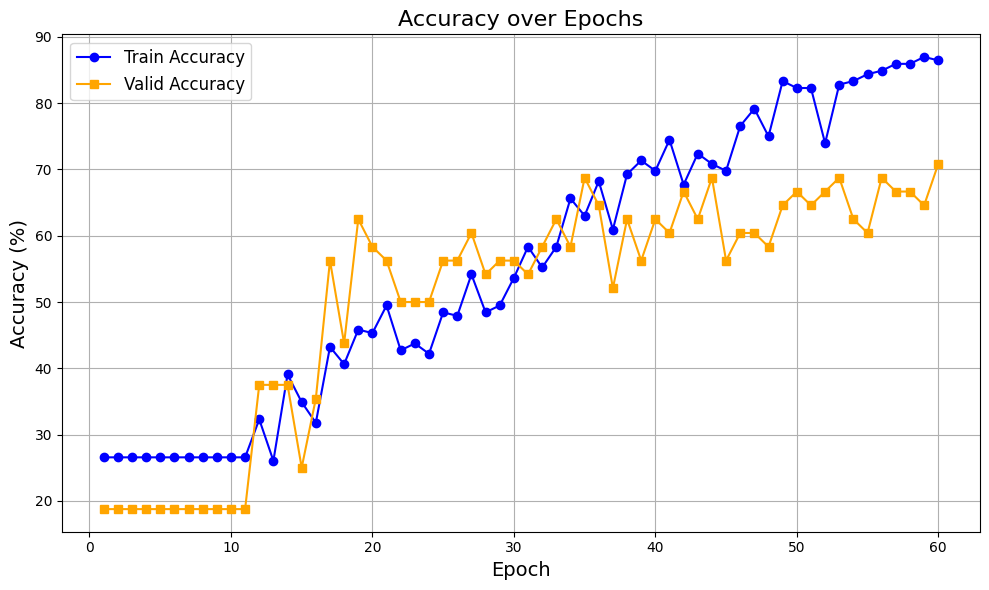

In [ ]:
# グラフのプロット（折れ線グラフ）
plt.figure(figsize=(10, 6))
# Convert CuPy arrays to NumPy arrays using .get() before plotting
plt.plot(range(1, num_epochs + 1), [100 * acc.get() for acc in train_accs], label='Train Accuracy', linestyle='-', marker='o', color='blue')
plt.plot(range(1, num_epochs + 1), [100 * acc.get() for acc in valid_accs], label='Valid Accuracy', linestyle='-', marker='s', color='orange')
plt.title('Accuracy over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### 保存したパラメーターの確認

In [ ]:
model = SimpleNet(arch, num_class, (32, 32))
model.load_params('/content/param.pkl')

# 学習最後の結果が再現できることを確認する。
train_acc = calc_acc(model, x_train, t_train, batch_size)
valid_acc = calc_acc(model, x_valid, t_valid, batch_size)
print(f'Train acc.:{100.*train_acc:.2f}%, Valid acc.:{100.*valid_acc:.2f}%')


# Test
npz = np.load('/content/drive/MyDrive/images_data.npz')
X = npz['images']#入力
X = X.transpose(0, 3, 1, 2).astype(np.float16)
X /= 255.
T = npz['labels']#出力
n_labels = len(np.unique(T))
T = np.eye(n_labels)[T].astype(np.float16)
print(X.shape, T.shape)
test_acc = calc_acc(model, X, T, batch_size)
print(f'Test acc.:{100.*test_acc:.2f}%')

fc1 in_ch size 128 (32 x 2 x 2)
Train acc.:86.46%, Valid acc.:70.83%
(240, 3, 32, 32) (240, 4)
Test acc.:83.33%


image: africa
predict: africa


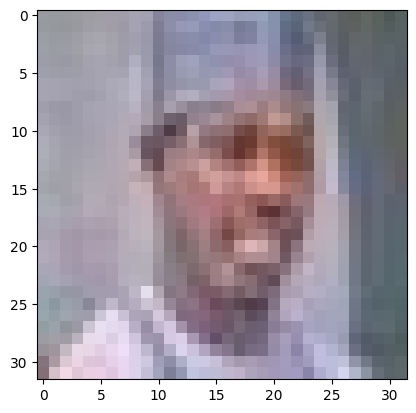

In [ ]:
# 各画像ごとにテストする場合
npz = np.load('/content/drive/MyDrive/images_data.npz')
X = npz['images']#入力
T = npz['labels']#出力

target = 16
img = X[target]
label = T[target]
print('image:', c_names[label.item()])
plt.imshow(img.get())

img = img[np.newaxis]
img = img.transpose(0, 3, 1, 2).astype(np.float16) / 255.
y = model.forward(img)
y = np.argmax(y, axis=1)
print('predict:', c_names[y.item()])

In [ ]:
def calc_class_accuracy(model, x, t, batch):
    """
    各クラスの正解率を計算する関数
    Args:
        model: 学習済みモデル
        x: 入力データ (画像)
        t: ラベル (one-hot)
        batch: バッチサイズ

    Returns:
        class_accuracies: 各クラスの正解率のリスト
    """
    # クラスごとの正解数とサンプル数
    correct_per_class = np.zeros(len(c_names), dtype=int)
    total_per_class = np.zeros(len(c_names), dtype=int)

    # ラベルをone-hotから整数に変換
    t_labels = np.argmax(t, axis=1)

    # モデルの予測を取得し、正解数を更新
    for i in range(0, len(x), batch):
        x_batch = x[i:i + batch].copy()
        t_batch = t_labels[i:i + batch].copy()

        y_batch = model.forward(x_batch)
        y_pred = np.argmax(y_batch, axis=1)

        for label in range(len(c_names)):
            correct_per_class[label] += np.sum((y_pred == label) & (t_batch == label))
            total_per_class[label] += np.sum(t_batch == label)

    # クラスごとの精度を計算
    class_accuracies = 100.0 * correct_per_class / np.maximum(total_per_class, 1)
    return class_accuracies


In [ ]:
model = SimpleNet(arch, num_class, (32, 32))
model.load_params('param.pkl')

# 各クラスの精度
print("\nClass-wise accuracies on validation data:")
class_accuracies = calc_class_accuracy(model, x_valid, t_valid, batch_size)
for class_idx, accuracy in enumerate(class_accuracies):
    print(f"{c_names[class_idx]}: {accuracy:.2f}%")

fc1 in_ch size 128 (32 x 2 x 2)

Class-wise accuracies on validation data:
euro: 83.33%
tyuutou: 66.67%
asia: 64.71%
africa: 70.00%


In [ ]:
arch = {
    'conv1': (16, 3, 5, 5, 1, 1, 1),
    'relu1': None,
    'conv2': (16, 16, 5, 5, 1, 1, 1),
    'relu2': None,
    'pool1': (2, 2, 2, 2, True),

    'conv3': (32, 16, 5, 5, 1, 1, 1),
    'relu3': None,
    'conv4': (32, 32, 5, 5, 1, 1, 1),
    'relu4': None,
    'pool2': (2, 2, 2, 2, True),

    'fc1' : [None, 128],
    'relu5': None,
    'dropout1': 0.4,

    'fc2' : (128, 128),
    'relu6': None,
    'dropout2': 0.4,

    'fc3' : (128, num_class),
}
num_epochs = 150
batch_size = 128